# Basado en [A Survey on Deep Neural Networks in Collaborative Filtering Recommendation Systems](https://arxiv.org/abs/2412.01378)



# Load data

In [1]:
cd ..

/home/adrian/git_repos/recommender_systems


/home/adrian/git_repos/recommender_systems/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
from collaborative import diagnose_cold_start, print_cold_start_report
from collaborative import ColdStartStatus
import os

In [3]:
train_data = pl.read_csv("./data/collaborative_filtering/train.csv")
test_data = pl.read_csv("./data/collaborative_filtering/test.csv")
train_data.head()

user,item,rating
i64,i64,f64
1,25715,7.0
1,25716,10.0
5,25851,9.0
6,25923,5.0
7,25924,6.0


In [4]:
train_shuffled = train_data.sample(fraction=1.0, shuffle=True, seed=42)

split_idx = int(0.8 * train_shuffled.height)

train_subset = train_shuffled[:split_idx]
eval_set = train_shuffled[split_idx:]

def attach_status_polars(df: pl.DataFrame, status_map: dict[int, ColdStartStatus]) -> pl.DataFrame:
    # Convertimos el Enum a string (.name) para que Polars trabaje con tipo de dato String nativo
    status_list = [status_map[i].name for i in range(df.height)]
    
    return df.with_columns(
        pl.Series("status", status_list)
    )

# 1. Seleccionamos columnas originales
train_df = train_subset.select(["user", "item", "rating"])
eval_df  = eval_set.select(["user", "item", "rating"])

# 2. Preparamos el array de train (user_id, item_id, rating) -> índices 0 y 1. Esto es correcto.
train_np = train_df.to_numpy()
eval_np = eval_df.to_numpy()

# Añadimos una columna contador porque lo pide la fx
eval_np = (
    eval_df
    .with_row_index("id")  # crea columna id = índice
    .select(["id", "user", "item"])
    .to_numpy()
)


# 4. Diagnóstico pasándole los arrays con los índices correctos
status_map_eval, summary_eval = diagnose_cold_start(train_np, eval_np)


# 5. Añadir columna status 

eval_df = attach_status_polars(eval_df, status_map_eval)
# train_df = attach_status_polars(train_df, status_map_train)


def split_by_status(df: pl.DataFrame):
    return {
        "ok": df.filter(pl.col("status") == ColdStartStatus.OK.name),
        "cold_user": df.filter(pl.col("status") == ColdStartStatus.COLD_USER.name),
        "unknown_item": df.filter(pl.col("status") == ColdStartStatus.UNKNOWN_ITEM.name),
        "both": df.filter(pl.col("status") == ColdStartStatus.BOTH.name),
    }

eval_splits = split_by_status(eval_df)
# train_splits = split_by_status(train_df)

eval_ok = eval_splits["ok"]
eval_cold_user = eval_splits["cold_user"]
eval_unknown_item = eval_splits["unknown_item"]
eval_both = eval_splits["both"]

# train_ok = train_splits["ok"]
# train_cold_user = train_splits["cold_user"]
# train_unknown_item = train_splits["unknown_item"]
# train_both = train_splits["both"]


print("Eval summary (from function):", summary_eval)
print("Eval counts (from df):")
print(print_cold_start_report(summary_eval))

# print("Train summary (from function):", summary_train)
# print("Train counts (from df):")
# print(count_by_status(train_df))

Eval summary (from function): {'ok': 45297, 'cold_user': 6657, 'unknown_item': 23249, 'both': 2868}
Eval counts (from df):
================= Cold-start diagnosis =================
  OK (user + item in train)            45,297  ( 58.0 %)
  Cold user  (user not in train)        6,657  (  8.5 %)
  Unknown item (item not in train)     23,249  ( 29.8 %)
  Both missing                          2,868  (  3.7 %)
  Total                                78,071
None


In [5]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Definir el formato de los datos
# Para poder trabajar con deep learning tenemos que pasar los IDs de 
# usuarios e items a un vector numerico continuo
folder_path = "./ml_assets"
os.makedirs(folder_path, exist_ok=True)
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_df = train_df.with_columns([
    pl.Series("user_idx", user_enc.fit_transform(train_df["user"].to_numpy())),
    pl.Series("item_idx", item_enc.fit_transform(train_df["item"].to_numpy()))
])
eval_ok = eval_ok.with_columns([
    pl.Series("user_idx", user_enc.transform(eval_ok["user"].to_numpy())),
    pl.Series("item_idx", item_enc.transform(eval_ok["item"].to_numpy()))
])

N_USERS = len(user_enc.classes_)
N_ITEMS = len(item_enc.classes_)

joblib.dump(user_enc, os.path.join(folder_path, 'user_encoder.joblib'))
joblib.dump(item_enc, os.path.join(folder_path, 'item_encoder.joblib'))


['./ml_assets/item_encoder.joblib']

# Modelo de Deep Learning


In [6]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim=8, layers=[64, 32, 16, 8], min_rating = 1, max_rating = 10, dropout=0.2):
        super(NeuMF, self).__init__()
        self.min_rating = min_rating
        self.max_rating = max_rating
        
        # --- Rama GMF ---
        # Embeddings para la Factorización de Matrices Generalizada
        self.embedding_user_GMF = nn.Embedding(num_users, latent_dim)
        self.embedding_item_GMF = nn.Embedding(num_items, latent_dim)
        
        # --- Rama MLP ---
        # Embeddings para el Perceptrón Multicapa
        self.embedding_user_MLP = nn.Embedding(num_users, layers[0] // 2)
        self.embedding_item_MLP = nn.Embedding(num_items, layers[0] // 2)
        
        # Capas ocultas del MLP
        mlp_modules = []
        for i in range(len(layers) - 1):
            mlp_modules.append(nn.Linear(layers[i], layers[i+1]))
            mlp_modules.append(nn.ReLU())
            mlp_modules.append(nn.Dropout(dropout))
        self.mlp_network = nn.Sequential(*mlp_modules)
        
        # --- Capa de Predicción Final ---
        # Combina la salida de GMF (dimensión latent_dim) y MLP (dimensión layers[-1])
        predict_size = latent_dim + layers[-1]
        self.prediction_layer = nn.Linear(predict_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        # Procesamiento GMF
        user_gmf = self.embedding_user_GMF(user_indices)
        item_gmf = self.embedding_item_GMF(item_indices)
        mf_vector = torch.mul(user_gmf, item_gmf) # Producto elemental
        
        # Procesamiento MLP
        user_mlp = self.embedding_user_MLP(user_indices)
        item_mlp = self.embedding_item_MLP(item_indices)
        # Concatenación de vectores
        mlp_vector = torch.cat([user_mlp, item_mlp], dim=-1)
        mlp_vector = self.mlp_network(mlp_vector)
        
        # Fusión y Predicción 
        combined_vector = torch.cat([mf_vector, mlp_vector], dim=-1)
        prediction = self.prediction_layer(combined_vector)
    
        return (self.min_rating + (self.max_rating - self.min_rating) * self.sigmoid(prediction)).view(-1)


# Torch dataset

In [7]:
from torch.utils.data import Dataset, DataLoader

class NCFDataset(Dataset):
    def __init__(self, df: pl.DataFrame):
        # Convertimos columnas de Polars a Tensores de PyTorch
        self.users = torch.tensor(df["user_idx"].to_numpy(), dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].to_numpy(), dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Crear instancias para entrenamiento y validación
train_dataset = NCFDataset(train_df)
eval_dataset = NCFDataset(eval_ok)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=256, shuffle=False)

# Entrenamiento

Running on cpu
Epoch 1, Train: 3.7080, Val: 3.1440
Epoch 2, Train: 3.2111, Val: 2.9620
Epoch 3, Train: 2.9379, Val: 2.8378
Epoch 4, Train: 2.7001, Val: 2.7994
Epoch 5, Train: 2.4652, Val: 2.8121
Epoch 6, Train: 2.2285, Val: 2.8874
Early stopping


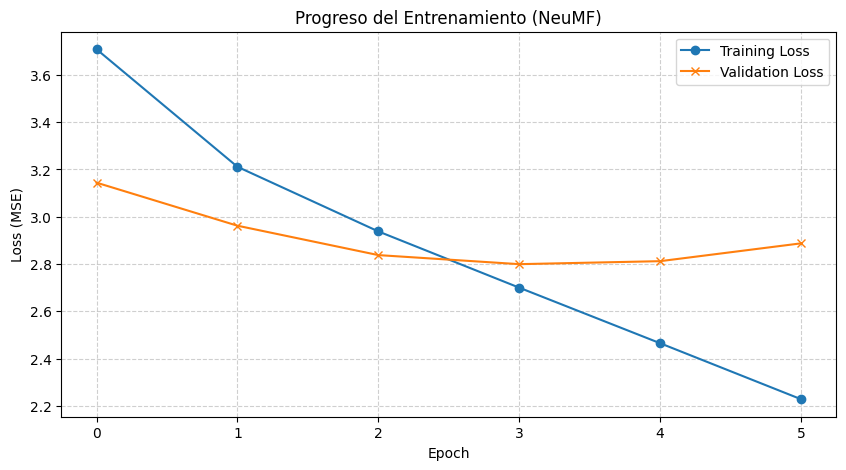

In [8]:
# Parámetros basados en tus encoders
model = NeuMF(num_users=N_USERS, num_items=N_ITEMS, latent_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Bucle de entrenamiento simplificado
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")
model.to(device)

import matplotlib.pyplot as plt

train_losses = []
val_losses = []
model.to(device)
best_val = float("inf")
patience = 2
counter = 0
for epoch in range(10):
    model.train()
    epoch_loss = 0
    for batch_user, batch_item, batch_rating in train_loader:
        batch_user, batch_item, batch_rating = batch_user.to(device), batch_item.to(device), batch_rating.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_user, batch_item)
        loss = criterion(predictions, batch_rating)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    # Eval
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for u, i, r in eval_loader:
            u, i, r = u.to(device), i.to(device), r.to(device)
            preds = model(u, i)
            loss = criterion(preds, r)
            val_loss += loss.item()

    val_loss /= len(eval_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {avg_loss:.4f}, Val: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# --- Generación del Plot ---
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')

plt.title('Progreso del Entrenamiento (NeuMF)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Optimización con optuna


In [9]:
import optuna
import torch
import torch.nn as nn

def objective(trial):
    # --- Espacio de búsqueda ---
    latent_dim = trial.suggest_categorical("latent_dim", [16,32, 64, 128])
    
    n_layers = trial.suggest_int("n_layers", 1, 3)
    layers = []
    input_size = trial.suggest_categorical("first_layer", [8, 16, 32])
    
    for i in range(n_layers):
        layers.append(input_size // (2**i))
    
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # --- Modelo ---
    model = NeuMF(
        num_users=N_USERS,
        num_items=N_ITEMS,
        latent_dim=latent_dim,
        layers=layers,
        dropout = dropout
    )


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.L1Loss()

    best_val = float("inf")
    patience = 3
    counter = 0

    # --- Entrenamiento ---
    for epoch in range(20):  # menos epochs para tuning
        model.train()
        for batch_user, batch_item, batch_rating in train_loader:
            batch_user = batch_user.to(device)
            batch_item = batch_item.to(device)
            batch_rating = batch_rating.to(device)

            optimizer.zero_grad()
            preds = model(batch_user, batch_item).float()
            loss = criterion(preds, batch_rating)
            loss.backward()
            optimizer.step()

        # --- Validación ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for u, i, r in eval_loader:
                u, i, r = u.to(device), i.to(device), r.to(device)
                preds = model(u, i).clamp(1, 10)
                loss = criterion(preds, r)
                val_loss += loss.item()

        val_loss /= len(eval_loader)

        # Pruning zzz
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    return best_val

In [10]:
import optuna

storage_name = "sqlite:///optuna/optuna_study.db"

study = optuna.create_study(
    study_name="deep_learning",
    storage=storage_name,              
    load_if_exists=True,
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3)
)

study.optimize(objective, n_trials=30)

[I 2026-03-25 17:18:13,760] A new study created in RDB with name: deep_learning
[I 2026-03-25 18:01:53,042] Trial 0 finished with value: 1.2356033540714932 and parameters: {'latent_dim': 64, 'n_layers': 1, 'first_layer': 32, 'lr': 0.0002873752615264152, 'weight_decay': 3.550243475402683e-05, 'dropout': 0.010960746461164739}. Best is trial 0 with value: 1.2356033540714932.
[W 2026-03-25 18:03:44,920] Trial 1 failed with parameters: {'latent_dim': 16, 'n_layers': 1, 'first_layer': 16, 'lr': 0.000774341493807537, 'weight_decay': 2.2882455507242642e-06, 'dropout': 0.3765478273453818} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/adrian/git_repos/recommender_systems/.venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_260156/1327218865.py", line 52, in objective
    optimizer.step()
  File "/home/adrian/git_repos/recommender_systems/.venv/lib/pyt

KeyboardInterrupt: 

In [11]:
print("Best trial:")
trial = study.best_trial

print(f"  Loss: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Loss: 1.2356033540714932
  Params: 
    latent_dim: 64
    n_layers: 1
    first_layer: 32
    lr: 0.0002873752615264152
    weight_decay: 3.550243475402683e-05
    dropout: 0.010960746461164739


# Entrenamiento del mejor caso e inferencia de test

In [12]:
from collaborative import diagnose_cold_start, print_cold_start_report, ColdStartStatus
import numpy as np
# Cargamos el train set de disco:
train_data = pl.read_csv("./data/collaborative_filtering/train.csv")
test_data = pl.read_csv("./data/collaborative_filtering/test.csv")
print("Train")
print(train_data.head())
print("Test")
print(test_data.head())
# Diagnose cold start
status_map_test, summary_test = diagnose_cold_start(train_data.to_numpy(), test_data.to_numpy())
test_df = attach_status_polars(test_data, status_map_test)
eval_splits = split_by_status(test_df)

test_ok = eval_splits["ok"]
test_cold_user = eval_splits["cold_user"]
test_unknown_item = eval_splits["unknown_item"]
test_both = eval_splits["both"]

# Setup de col start
from collaborative.cold_start import AsymmetricMedianDampingFallback

cold_start_handler = AsymmetricMedianDampingFallback(
user_damping_factor=0.5,
item_damping_factor=11.0
)

# Usamos train original (sin encoding)
cold_start_handler.setup(train_data.to_numpy())

# Pasamos labels de items y users a arraycontinuo con labelencoder
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_data = train_data.with_columns([
    pl.Series("user_idx", user_enc.fit_transform(train_data["user"].to_numpy())),
    pl.Series("item_idx", item_enc.fit_transform(train_data["item"].to_numpy()))
])
train_dataset = NCFDataset(train_data)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_ok = test_ok.with_columns([
    pl.Series("user_idx", user_enc.transform(test_ok["user"].to_numpy())),
    pl.Series("item_idx", item_enc.transform(test_ok["item"].to_numpy()))
])

N_USERS = len(user_enc.classes_)
N_ITEMS = len(item_enc.classes_)

# Instanciamos el modelo y optimizer
best_params = study.best_params

model = NeuMF(
num_users=N_USERS,
num_items=N_ITEMS,
latent_dim=best_params["latent_dim"],
layers=[best_params["first_layer"] // (2**i) for i in range(best_params["n_layers"])],
dropout = best_params["dropout"]
)

optimizer = torch.optim.Adam(
model.parameters(),
lr=best_params["lr"],
weight_decay=best_params["weight_decay"]
)


# Entrenamiento con todo train_set
epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.train()
for epoch in range(epochs):
    total_loss = 0

    for u, i, r in train_loader:
        u, i, r = u.to(device), i.to(device), r.to(device)

        optimizer.zero_grad()
        preds = model(u, i)
        loss = criterion(preds, r)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")
# Inferencia sobre test_set
model.eval()

predictions = []
for idx in range(len(test_df)):
    row = test_df.row(idx)

    test_id = int(row[0]) # ID
    user_id = int(row[1]) # user original
    item_id = int(row[2]) # item original

    status = status_map_test[idx]

    if status == ColdStartStatus.OK:
        # --- usar NeuMF ---
        try:
            user_idx = user_enc.transform([user_id])[0]
            item_idx = item_enc.transform([item_id])[0]

            u = torch.tensor([user_idx], dtype=torch.long).to(device)
            i = torch.tensor([item_idx], dtype=torch.long).to(device)

            with torch.no_grad():
                pred = model(u, i).item()

        except Exception:
            # fallback si algo falla
            pred = cold_start_handler.predict(user_id, item_id, status)

    else:
        # --- cold start handler ---
        pred = cold_start_handler.predict(user_id, item_id, status)

        # clamp + redondeo EXACTO como script
        pred = int(np.clip(np.rint(pred), 1, 10))

        predictions.append([test_id, pred])

Train
shape: (5, 3)
┌──────┬───────┬────────┐
│ user ┆ item  ┆ rating │
│ ---  ┆ ---   ┆ ---    │
│ i64  ┆ i64   ┆ f64    │
╞══════╪═══════╪════════╡
│ 1    ┆ 25715 ┆ 7.0    │
│ 1    ┆ 25716 ┆ 10.0   │
│ 5    ┆ 25851 ┆ 9.0    │
│ 6    ┆ 25923 ┆ 5.0    │
│ 7    ┆ 25924 ┆ 6.0    │
└──────┴───────┴────────┘
Test
shape: (5, 3)
┌─────┬───────┬───────┐
│ ID  ┆ user  ┆ item  │
│ --- ┆ ---   ┆ ---   │
│ i64 ┆ i64   ┆ i64   │
╞═════╪═══════╪═══════╡
│ 0   ┆ 8117  ┆ 268   │
│ 1   ┆ 10512 ┆ 24393 │
│ 2   ┆ 534   ┆ 1334  │
│ 3   ┆ 10984 ┆ 6550  │
│ 4   ┆ 9093  ┆ 22128 │
└─────┴───────┴───────┘
Epoch 1 - Loss: 0.0055
Epoch 1 - Loss: 0.0109
Epoch 1 - Loss: 0.0165
Epoch 1 - Loss: 0.0222
Epoch 1 - Loss: 0.0272
Epoch 1 - Loss: 0.0324
Epoch 1 - Loss: 0.0382
Epoch 1 - Loss: 0.0438
Epoch 1 - Loss: 0.0492
Epoch 1 - Loss: 0.0544
Epoch 1 - Loss: 0.0592
Epoch 1 - Loss: 0.0645
Epoch 1 - Loss: 0.0696
Epoch 1 - Loss: 0.0754
Epoch 1 - Loss: 0.0802
Epoch 1 - Loss: 0.0855
Epoch 1 - Loss: 0.0910
Epoch 1 - Loss: 0.09

KeyboardInterrupt: 